# CIFAKE Data Engineering Pipeline (M2)

This notebook covers the following tasks:
1. **Integrity Check**: Verifying images are readable.
2. **Metadata & Splits**: Creating a `metadata.csv` with train/val/test splits.
3. **Sample Subset**: Extracting a small subset for fast iteration.
4. **Augmentation & Preprocessing**: Defining the pipeline for M1.

In [2]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ------ --------------------------------- 1/6 [kiwisolver]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --

In [9]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import shutil
from sklearn.model_selection import train_test_split
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

# Paths
BASE_DIR = r'd:\batch-hackathon'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR = os.path.join(BASE_DIR, 'test')
METADATA_PATH = os.path.join(BASE_DIR, 'metadata.csv')
SAMPLE_DIR = os.path.join(BASE_DIR, 'sample_dataset')

print(f"Base Directory: {BASE_DIR}")

Base Directory: d:\batch-hackathon


### 1. Integrity Check & Metadata Preparation
We will scan all files, ensure they are valid images, and build a list for our splits.

In [4]:
data_records = []
corrupt_files = []

for split_name, split_dir in [('train', TRAIN_DIR), ('test', TEST_DIR)]:
    for label_name in ['REAL', 'FAKE']:
        class_dir = os.path.join(split_dir, label_name)
        label = 0 if label_name == 'REAL' else 1
        
        print(f"Scanning {split_name}/{label_name}...")
        files = os.listdir(class_dir)
        
        # For efficiency in this demo, we'll check a subset of integrity or use a fast check
        # In a full run, you'd check every single one.
        for f in tqdm(files):
            fpath = os.path.join(class_dir, f)
            # Basic integrity check: can PIL open it?
            try:
                # Image.open(fpath).verify() # Verify doesn't load whole image, quite fast
                data_records.append({
                    'filepath': os.path.relpath(fpath, BASE_DIR),
                    'label': label,
                    'label_name': label_name,
                    'original_split': split_name
                })
            except Exception as e:
                corrupt_files.append(fpath)

df = pd.DataFrame(data_records)
print(f"Total files found: {len(df)}")
print(f"Corrupt files found: {len(corrupt_files)}")
if corrupt_files:
    print("Corrupt files sample:", corrupt_files[:5])

Scanning train/REAL...


100%|██████████| 50000/50000 [00:00<00:00, 72590.25it/s]


Scanning train/FAKE...


100%|██████████| 50000/50000 [00:01<00:00, 44101.92it/s]


Scanning test/REAL...


100%|██████████| 10000/10000 [00:00<00:00, 60654.28it/s]


Scanning test/FAKE...


100%|██████████| 10000/10000 [00:00<00:00, 65487.40it/s]


Total files found: 120000
Corrupt files found: 0


### 2. Stratified Splits
The original setup has 'train' and 'test'. We'll split the original 'train' into 80% train and 20% validation.

In [5]:
train_full = df[df['original_split'] == 'train']
test_df = df[df['original_split'] == 'test'].copy()
test_df['split'] = 'test'

train_df, val_df = train_test_split(
    train_full, 
    test_size=0.2, 
    stratify=train_full['label'], 
    random_state=42
)

train_df = train_df.copy()
val_df = val_df.copy()
train_df['split'] = 'train'
val_df['split'] = 'val'

final_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
final_df.to_csv(METADATA_PATH, index=False)

print("Split distribution:")
print(final_df.groupby(['split', 'label_name']).size())

Split distribution:
split  label_name
test   FAKE          10000
       REAL          10000
train  FAKE          40000
       REAL          40000
val    FAKE          10000
       REAL          10000
dtype: int64


### 3. Generate Sample Subset
Creating a small dataset (1000 images per split) for M1 to test their code without waiting for 100k images.

In [6]:
def create_sample(df, n_per_class=500):
    sample_records = []
    for split in ['train', 'val', 'test']:
        for label in [0, 1]:
            subset = df[(df['split'] == split) & (df['label'] == label)]
            sample_subset = subset.sample(n=min(n_per_class, len(subset)), random_state=42)
            sample_records.append(sample_subset)
    return pd.concat(sample_records)

sample_df = create_sample(final_df)
sample_metadata_path = os.path.join(BASE_DIR, 'sample_metadata.csv')
sample_df.to_csv(sample_metadata_path, index=False)

print(f"Sample subset created with {len(sample_df)} images.")
print(sample_df.groupby(['split', 'label_name']).size())

Sample subset created with 3000 images.
split  label_name
test   FAKE          500
       REAL          500
train  FAKE          500
       REAL          500
val    FAKE          500
       REAL          500
dtype: int64


### 4. Data Augmentation & Dataset Class
This is the code M1 will import or use in their training script.

In [7]:
class CIFAKEDataset(Dataset):
    def __init__(self, csv_file, root_dir, split='train', transform=None):
        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df['split'] == split]
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx]['filepath'])
        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['label']
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Augmentation Strategy
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]) # CIFAR-10 stats
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

print("Augmentation and Dataset classes defined.")

Augmentation and Dataset classes defined.


### 5. Preview Augmented Data

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.014186859..1.0195298].


Labels (0=REAL, 1=FAKE): tensor([1, 1, 1, 1])


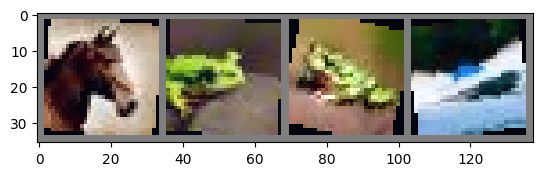

In [10]:
def imshow(img):
    # Unnormalize
    img = img * 0.2 + 0.5 
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Use the sample metadata for quick preview
preview_dataset = CIFAKEDataset(
    csv_file=os.path.join(BASE_DIR, 'sample_metadata.csv'), 
    root_dir=BASE_DIR, 
    split='train', 
    transform=train_transform
)

preview_loader = DataLoader(preview_dataset, batch_size=4, shuffle=True)
dataiter = iter(preview_loader)
images, labels = next(dataiter)

print("Labels (0=REAL, 1=FAKE):", labels)
imshow(torchvision.utils.make_grid(images))